<a href="https://colab.research.google.com/github/Minsoo1036/Applied-Data-Analysis-Study/blob/main/MultiOutputRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

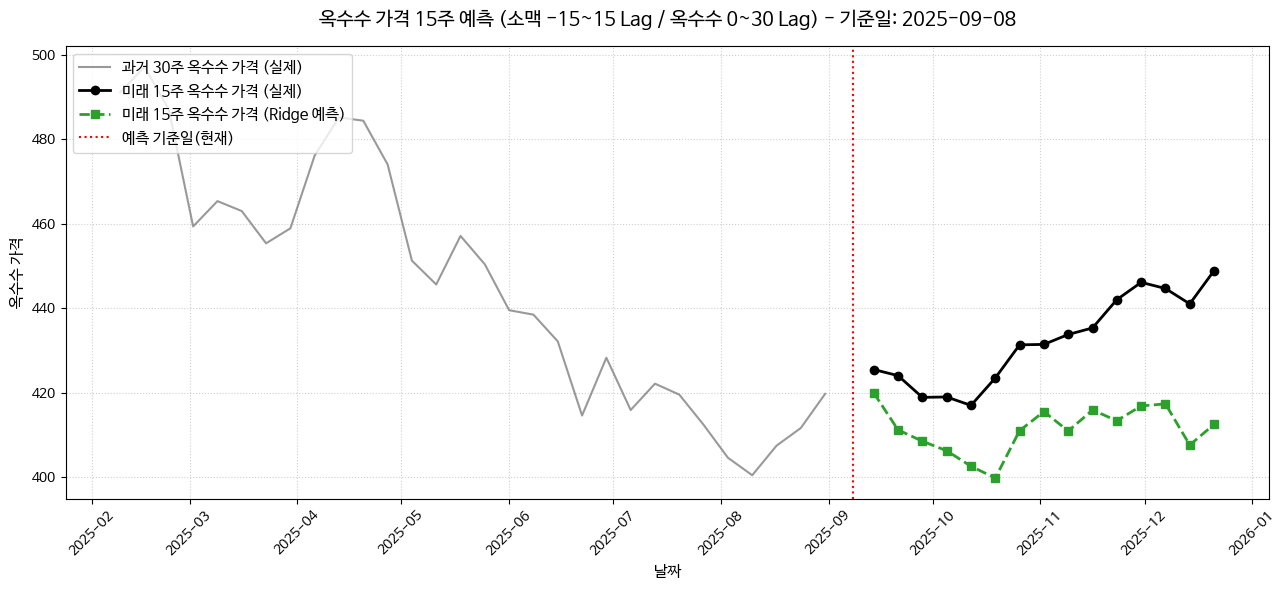

In [3]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. Colab/OS 한글 폰트 및 마이너스 부호 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  # 로컬 환경 대체
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. Target 및 Lag Feature 생성 (요청사항 100% 반영)
# -------------------------------------------------------------
# (가정: df에 'date', 'corn', 'wheat' 컬럼이 존재함)

# A. Target: 향후 15주 옥수수 가격 차분 (Corn_lead_1 ~ 15 - 현재 Corn)
#    * 레벨 문제 해결을 위해 현재 가격 대비 '변화량(Diff)'으로 Target 설정
for i in range(1, 16):
  df[f'corn_diff_lead_{i}'] = df['corn'].shift(-i) - df['corn']

# B. Wheat Lag Feature: -15주 ~ +15주
for i in range(-15, 16):
  # i가 음수면 shift(-i) -> 미래 값, i가 양수면 shift(i) -> 과거 값
  df[f'wheat_lag_{i}'] = df['wheat'].shift(i)

# C. Corn Lag Feature: 0주 ~ 30주 (과거 30주)
for i in range(0, 31):
  df[f'corn_lag_{i}'] = df['corn'].shift(i)

# 결측치(Shift로 생성된 NaN) 제거
df_clean = df.dropna().copy()

# -------------------------------------------------------------
# 2. X, y Feature 컬럼 지정
# -------------------------------------------------------------
wheat_cols = [f'wheat_lag_{i}' for i in range(-15, 16)]  # -15 ~ 15
corn_lag_cols = [f'corn_lag_{i}' for i in range(0, 31)]  # 0 ~ 30

X_cols = wheat_cols + corn_lag_cols
y_diff_cols = [f'corn_diff_lead_{i}' for i in range(1, 16)]  # 15주 미래 차분

X = df_clean[X_cols]
y_diff = df_clean[y_diff_cols]

# Train/Test Split (8:2)
train_size = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train_diff, y_test_diff = y_diff.iloc[:train_size], y_diff.iloc[train_size:]

# -------------------------------------------------------------
# 3. Ridge 차분 모델 학습
# -------------------------------------------------------------
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0))
ridge_model.fit(X_train, y_train_diff)

# -------------------------------------------------------------
# 4. 가장 최근 단일 인스턴스(1개 행) 추론 및 레벨 복원
# -------------------------------------------------------------
last_idx = -1
single_X_test = X_test.iloc[[last_idx]]  # 2D DataFrame 유지

# 예측 기준일 정보
base_date = pd.to_datetime(df_clean['date'].iloc[last_idx])
base_price = df_clean['corn'].iloc[last_idx]

# 15주 미래 차분 예측값 추론
pred_diff_15 = ridge_model.predict(single_X_test)[0]  # (15,) array

# 현재 가격을 더해 실제 옥수수 가격(Level)으로 복원
pred_price_15 = base_price + pred_diff_15

# 실제 미래 15주 가격 (비교용)
actual_diff_15 = y_test_diff.iloc[last_idx].values
actual_price_15 = base_price + actual_diff_15

# -------------------------------------------------------------
# 5. 시각화 (과거 30주 맥락 + 향후 15주 예측)
# -------------------------------------------------------------
# 날짜 인덱스 생성
past_dates = pd.date_range(end=base_date, periods=31, freq='W')[:-1]  # 과거 30주
future_dates = pd.date_range(start=base_date, periods=15, freq='W')  # 미래 15주

# 과거 30주 실제 옥수수 가격
hist_idx = df_clean.index[last_idx]
past_corn = df['corn'].iloc[hist_idx - 30 : hist_idx].values

plt.figure(figsize=(13, 6))

# 과거 30주 흐름
plt.plot(
    past_dates,
    past_corn,
    color='gray',
    label='과거 30주 옥수수 가격 (실제)',
    linewidth=1.5,
    alpha=0.8,
)

# 미래 15주 실제값
plt.plot(
    future_dates,
    actual_price_15,
    color='black',
    label='미래 15주 옥수수 가격 (실제)',
    marker='o',
    linewidth=2,
)

# 미래 15주 Ridge 예측값
plt.plot(
    future_dates,
    pred_price_15,
    color='#2ca02c',
    label='미래 15주 옥수수 가격 (Ridge 예측)',
    linestyle='--',
    marker='s',
    linewidth=2,
)

# 기준일 표시
plt.axvline(x=base_date, color='red', linestyle=':', label='예측 기준일(현재)')

plt.title(
    f'옥수수 가격 15주 예측 (소맥 -15~15 Lag / 옥수수 0~30 Lag) -'
    f' 기준일: {base_date.strftime("%Y-%m-%d")}',
    fontsize=14,
    pad=15,
)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('옥수수 가격', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000807 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

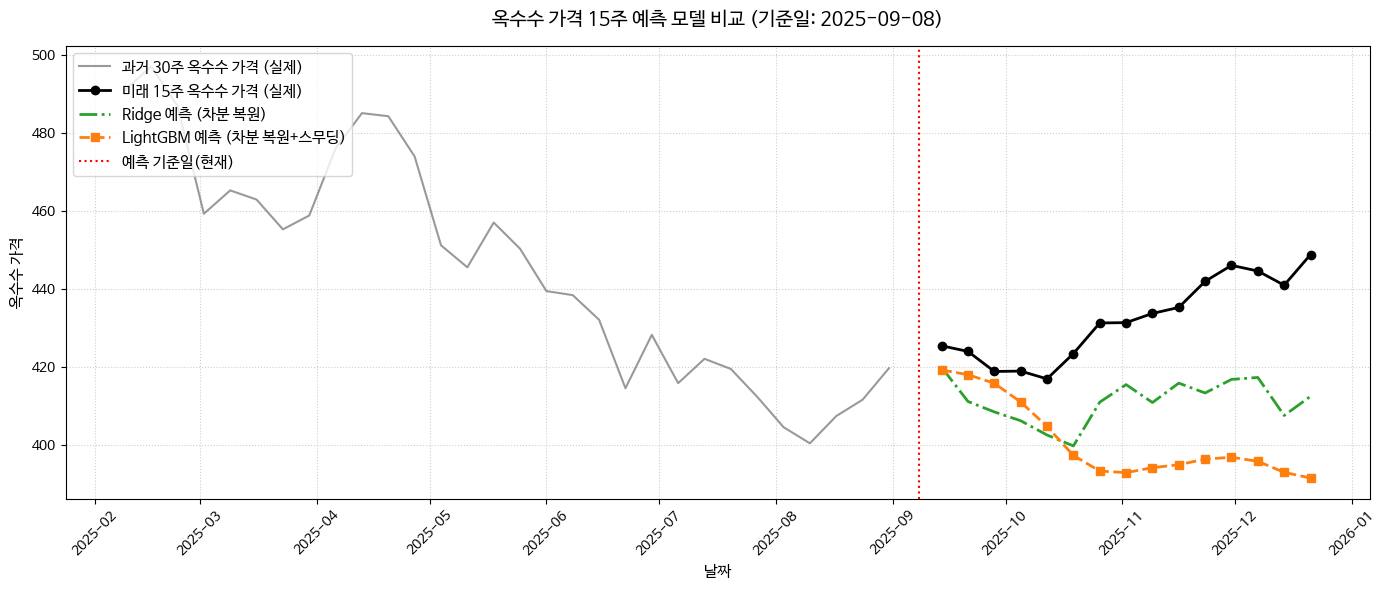

In [4]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. Colab/OS 한글 폰트 및 마이너스 부호 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. Target 및 Lag Feature 생성
# -------------------------------------------------------------
# A. Target: 향후 15주 옥수수 가격 차분 (Corn_lead_1 ~ 15 - 현재 Corn)
for i in range(1, 16):
  df[f'corn_diff_lead_{i}'] = df['corn'].shift(-i) - df['corn']

# B. Wheat Lag Feature: -15주 ~ +15주 (총 31개)
for i in range(-15, 16):
  df[f'wheat_lag_{i}'] = df['wheat'].shift(i)

# C. Corn Lag Feature: 0주 ~ 30주 (총 31개)
for i in range(0, 31):
  df[f'corn_lag_{i}'] = df['corn'].shift(i)

# 결측치 제거
df_clean = df.dropna().copy()

# -------------------------------------------------------------
# 2. X, y Feature 컬럼 지정
# -------------------------------------------------------------
wheat_cols = [f'wheat_lag_{i}' for i in range(-15, 16)]
corn_lag_cols = [f'corn_lag_{i}' for i in range(0, 31)]

X_cols = wheat_cols + corn_lag_cols
y_diff_cols = [f'corn_diff_lead_{i}' for i in range(1, 16)]

X = df_clean[X_cols]
y_diff = df_clean[y_diff_cols]

# Train/Test Split (8:2)
train_size = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train_diff, y_test_diff = y_diff.iloc[:train_size], y_diff.iloc[train_size:]

# -------------------------------------------------------------
# 3. 모델 학습 (Ridge & LightGBM)
# -------------------------------------------------------------
# [모델 1] Ridge
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0))
ridge_model.fit(X_train, y_train_diff)

# [모델 2] LightGBM (과적합 및 튐 방지 파라미터 적용)
lgbm_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=4,  # 트리가 깊어지지 않도록 제어
        subsample=0.8,
        colsample_bytree=0.6,  # 변수 60%만 랜덤 사용하여 특정 Lag 독점 방지
        random_state=42,
    )
)
lgbm_model.fit(X_train, y_train_diff)

# -------------------------------------------------------------
# 4. 가장 최근 단일 인스턴스(1개 행) 추론 및 레벨 복원
# -------------------------------------------------------------
last_idx = -1
single_X_test = X_test.iloc[[last_idx]]  # 2D DataFrame 형태 유지

base_date = pd.to_datetime(df_clean['date'].iloc[last_idx])
base_price = df_clean['corn'].iloc[last_idx]

# A. Ridge 추론 및 복원
pred_ridge_diff = ridge_model.predict(single_X_test)[0]
pred_ridge_price = base_price + pred_ridge_diff

# B. LightGBM 추론, 복원 및 스무딩(Smoothing)
pred_lgbm_diff = lgbm_model.predict(single_X_test)[0]
pred_lgbm_price = base_price + pred_lgbm_diff
# 3주 이동평균으로 꺾이는 곡선 다듬기
pred_lgbm_smoothed = (
    pd.Series(pred_lgbm_price)
    .rolling(window=3, min_periods=1, center=True)
    .mean()
    .values
)

# C. 실제 미래 15주 가격 (비교용)
actual_diff = y_test_diff.iloc[last_idx].values
actual_price = base_price + actual_diff

# -------------------------------------------------------------
# 5. 시각화 (과거 30주 맥락 + 향후 15주 Ridge vs LGBM 예측)
# -------------------------------------------------------------
past_dates = pd.date_range(end=base_date, periods=31, freq='W')[:-1]  # 과거 30주
future_dates = pd.date_range(start=base_date, periods=15, freq='W')  # 미래 15주

hist_idx = df_clean.index[last_idx]
past_corn = df['corn'].iloc[hist_idx - 30 : hist_idx].values

plt.figure(figsize=(14, 6))

# 과거 30주 흐름
plt.plot(
    past_dates,
    past_corn,
    color='gray',
    label='과거 30주 옥수수 가격 (실제)',
    linewidth=1.5,
    alpha=0.8,
)

# 미래 15주 실제값
plt.plot(
    future_dates,
    actual_price,
    color='black',
    label='미래 15주 옥수수 가격 (실제)',
    marker='o',
    linewidth=2,
)

# 미래 15주 Ridge 예측값
plt.plot(
    future_dates,
    pred_ridge_price,
    color='#2ca02c',
    label='Ridge 예측 (차분 복원)',
    linestyle='-.',
    linewidth=2,
)

# 미래 15주 LightGBM 예측값 (스무딩 적용)
plt.plot(
    future_dates,
    pred_lgbm_smoothed,
    color='#ff7f0e',
    label='LightGBM 예측 (차분 복원+스무딩)',
    linestyle='--',
    marker='s',
    linewidth=2,
)

# 예측 기준일 표시
plt.axvline(x=base_date, color='red', linestyle=':', label='예측 기준일(현재)')

plt.title(
    f'옥수수 가격 15주 예측 모델 비교 (기준일: {base_date.strftime("%Y-%m-%d")})',
    fontsize=14,
    pad=15,
)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('옥수수 가격', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

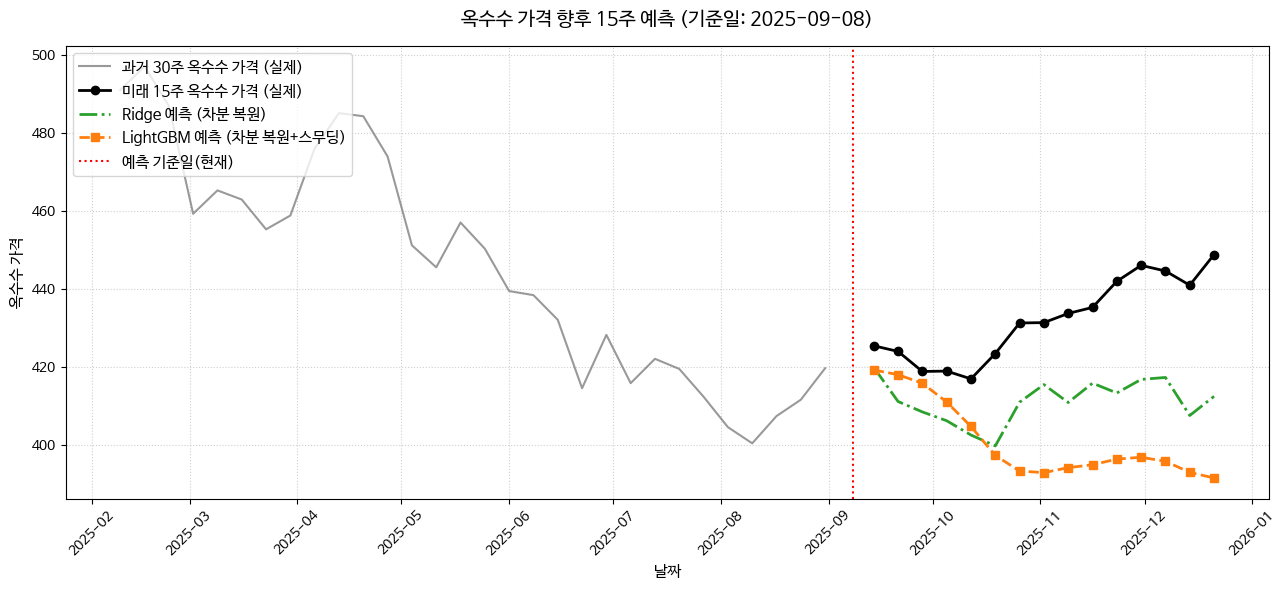

In [5]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. Target & Feature (15주 예측 맞춤)
# -------------------------------------------------------------
# Target: 미래 1~15주 옥수수 가격 변화량(Diff)
for i in range(1, 16):
  df[f'corn_diff_lead_{i}'] = df['corn'].shift(-i) - df['corn']

# Feature 1: Wheat Lag (-15 ~ +15주)
for i in range(-15, 16):
  df[f'wheat_lag_{i}'] = df['wheat'].shift(i)

# Feature 2: Corn Lag (0 ~ 30주)
for i in range(0, 31):
  df[f'corn_lag_{i}'] = df['corn'].shift(i)

df_clean = df.dropna().copy()

wheat_cols = [f'wheat_lag_{i}' for i in range(-15, 16)]
corn_lag_cols = [f'corn_lag_{i}' for i in range(0, 31)]

X_cols = wheat_cols + corn_lag_cols
y_diff_cols = [f'corn_diff_lead_{i}' for i in range(1, 16)]

X = df_clean[X_cols]
y_diff = df_clean[y_diff_cols]

# Train/Test Split
train_size = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train_diff, y_test_diff = y_diff.iloc[:train_size], y_diff.iloc[train_size:]

# -------------------------------------------------------------
# 2. 모델 학습
# -------------------------------------------------------------
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0)).fit(X_train, y_train_diff)

lgbm_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.6,
        random_state=42,
    )
).fit(X_train, y_train_diff)

# -------------------------------------------------------------
# 3. 단일 인스턴스 15주 추론 및 시각화
# -------------------------------------------------------------
last_idx = -1
single_X_test = X_test.iloc[[last_idx]]

base_date = pd.to_datetime(df_clean['date'].iloc[last_idx])
base_price = df_clean['corn'].iloc[last_idx]

# 추론 및 가격 복원
pred_ridge_price = base_price + ridge_model.predict(single_X_test)[0]

pred_lgbm_diff = lgbm_model.predict(single_X_test)[0]
pred_lgbm_price = base_price + pred_lgbm_diff
pred_lgbm_smoothed = (
    pd.Series(pred_lgbm_price)
    .rolling(window=3, min_periods=1, center=True)
    .mean()
    .values
)

actual_price = base_price + y_test_diff.iloc[last_idx].values

# 날짜 정의
past_dates = pd.date_range(end=base_date, periods=31, freq='W')[:-1]
future_dates = pd.date_range(start=base_date, periods=15, freq='W')

hist_idx = df_clean.index[last_idx]
past_corn = df['corn'].iloc[hist_idx - 30 : hist_idx].values

# Plot
plt.figure(figsize=(13, 6))

plt.plot(
    past_dates,
    past_corn,
    color='gray',
    label='과거 30주 옥수수 가격 (실제)',
    linewidth=1.5,
    alpha=0.8,
)
plt.plot(
    future_dates,
    actual_price,
    color='black',
    label='미래 15주 옥수수 가격 (실제)',
    marker='o',
    linewidth=2,
)
plt.plot(
    future_dates,
    pred_ridge_price,
    color='#2ca02c',
    label='Ridge 예측 (차분 복원)',
    linestyle='-.',
    linewidth=2,
)
plt.plot(
    future_dates,
    pred_lgbm_smoothed,
    color='#ff7f0e',
    label='LightGBM 예측 (차분 복원+스무딩)',
    linestyle='--',
    marker='s',
    linewidth=2,
)

plt.axvline(x=base_date, color='red', linestyle=':', label='예측 기준일(현재)')

plt.title(
    f'옥수수 가격 향후 15주 예측 (기준일: {base_date.strftime("%Y-%m-%d")})',
    fontsize=14,
    pad=15,
)
plt.xlabel('날짜', fontsize=11)
plt.ylabel('옥수수 가격', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.871e+04, tolerance: 1.886e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.036e+04, tolerance: 4.538e+01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.564e+04, tolerance: 7.330e

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

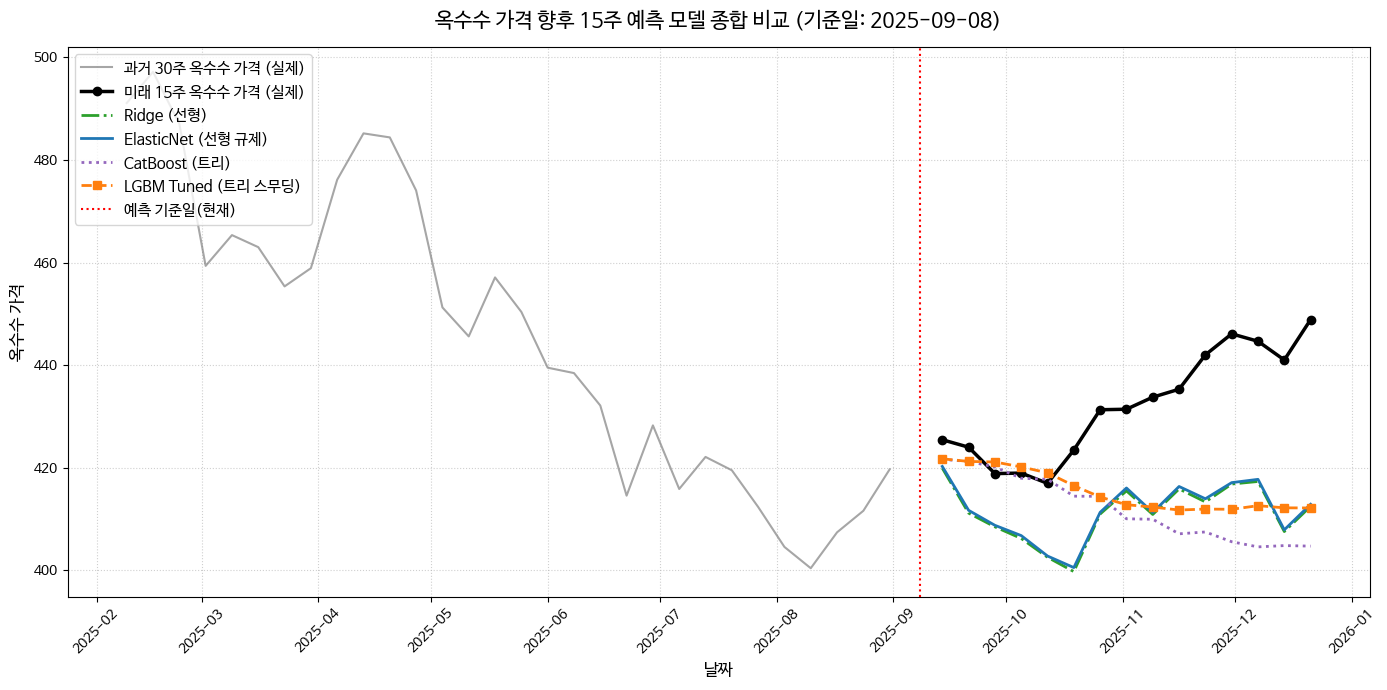

In [8]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. 한글 폰트 및 마이너스 부호 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. 모델 학습 (Ridge, ElasticNet, LightGBM Tuned, CatBoost)
# -------------------------------------------------------------
# A. Ridge (선형 베이스라인)
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0)).fit(
    X_train, y_train_diff
)

# B. ElasticNet (Ridge + Lasso 혼합: 매우 안정적)
elastic_model = MultiOutputRegressor(
    ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42)
).fit(X_train, y_train_diff)

# C. LightGBM (시계열 맞춤 다이어트 튜닝)
lgbm_tuned = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=60,
        learning_rate=0.02,
        max_depth=3,  # 깊이를 얕게 줄여 오버피팅/계단현상 억제
        num_leaves=7,
        min_child_samples=15,
        subsample=0.7,
        colsample_bytree=0.4,
        random_state=42,
    )
).fit(X_train, y_train_diff)

# D. CatBoost (트리 기반 시계열 최강자)
catboost_model = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=100, learning_rate=0.03, depth=3, verbose=0, random_seed=42
    )
).fit(X_train, y_train_diff)

# -------------------------------------------------------------
# 2. 단일 인스턴스 15주 추론 및 레벨 복원
# -------------------------------------------------------------
last_idx = -1
single_X_test = X_test.iloc[[last_idx]]

base_date = pd.to_datetime(df_clean['date'].iloc[last_idx])
base_price = df_clean['corn'].iloc[last_idx]

# 추론 및 가격 복원
pred_ridge = base_price + ridge_model.predict(single_X_test)[0]
pred_elastic = base_price + elastic_model.predict(single_X_test)[0]

# LightGBM 스무딩 적용
pred_lgbm_raw = base_price + lgbm_tuned.predict(single_X_test)[0]
pred_lgbm_smoothed = (
    pd.Series(pred_lgbm_raw)
    .rolling(window=3, min_periods=1, center=True)
    .mean()
    .values
)

# CatBoost 추론
pred_catboost = base_price + catboost_model.predict(single_X_test)[0]

# 실제값
actual_price = base_price + y_test_diff.iloc[last_idx].values

# -------------------------------------------------------------
# 3. 시각화 (과거 30주 맥락 + 4개 모델 15주 예측 비교)
# -------------------------------------------------------------
past_dates = pd.date_range(end=base_date, periods=31, freq='W')[:-1]
future_dates = pd.date_range(start=base_date, periods=15, freq='W')

hist_idx = df_clean.index[last_idx]
past_corn = df['corn'].iloc[hist_idx - 30 : hist_idx].values

plt.figure(figsize=(14, 7))

# 과거 30주 실제
plt.plot(
    past_dates,
    past_corn,
    color='gray',
    label='과거 30주 옥수수 가격 (실제)',
    linewidth=1.5,
    alpha=0.7,
)

# 미래 15주 실제
plt.plot(
    future_dates,
    actual_price,
    color='black',
    label='미래 15주 옥수수 가격 (실제)',
    marker='o',
    linewidth=2.5,
)

# 예측선들
plt.plot(
    future_dates,
    pred_ridge,
    color='#2ca02c',
    label='Ridge (선형)',
    linestyle='-.',
    linewidth=2,
)
plt.plot(
    future_dates,
    pred_elastic,
    color='#1f77b4',
    label='ElasticNet (선형 규제)',
    linestyle='-',
    linewidth=2,
)
plt.plot(
    future_dates,
    pred_catboost,
    color='#9467bd',
    label='CatBoost (트리)',
    linestyle=':',
    linewidth=2,
)
plt.plot(
    future_dates,
    pred_lgbm_smoothed,
    color='#ff7f0e',
    label='LGBM Tuned (트리 스무딩)',
    linestyle='--',
    marker='s',
    linewidth=2,
)

plt.axvline(x=base_date, color='red', linestyle=':', label='예측 기준일(현재)')

plt.title(
    f'옥수수 가격 향후 15주 예측 모델 종합 비교 (기준일:'
    f' {base_date.strftime("%Y-%m-%d")})',
    fontsize=15,
    pad=15,
)
plt.xlabel('날짜', fontsize=12)
plt.ylabel('옥수수 가격', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [2]:
df = pd.read_csv("/content/drive/MyDrive/df3.csv")

In [9]:
df_all = pd.read_csv("/content/drive/MyDrive/df3_all.csv")

In [12]:
instance = df_all.loc[df_all['date']=='2026-02-16',]

In [13]:
instance

,Unnamed: 0,date,corn,wheat,wheat_lag-30,wheat_lag-29,wheat_lag-28,wheat_lag-27,wheat_lag-26,wheat_lag-25,...,wheat_lag21,wheat_lag22,wheat_lag23,wheat_lag24,wheat_lag25,wheat_lag26,wheat_lag27,wheat_lag28,wheat_lag29,wheat_lag30
841,841,2026-02-16,426.625,557.9375,NaN,NaN,NaN,NaN,NaN,NaN,...,519.5,526.8,520.8,522.25,529.8,526.3,511.55,513.25,526.4,542.4


In [14]:
df_single_row = instance

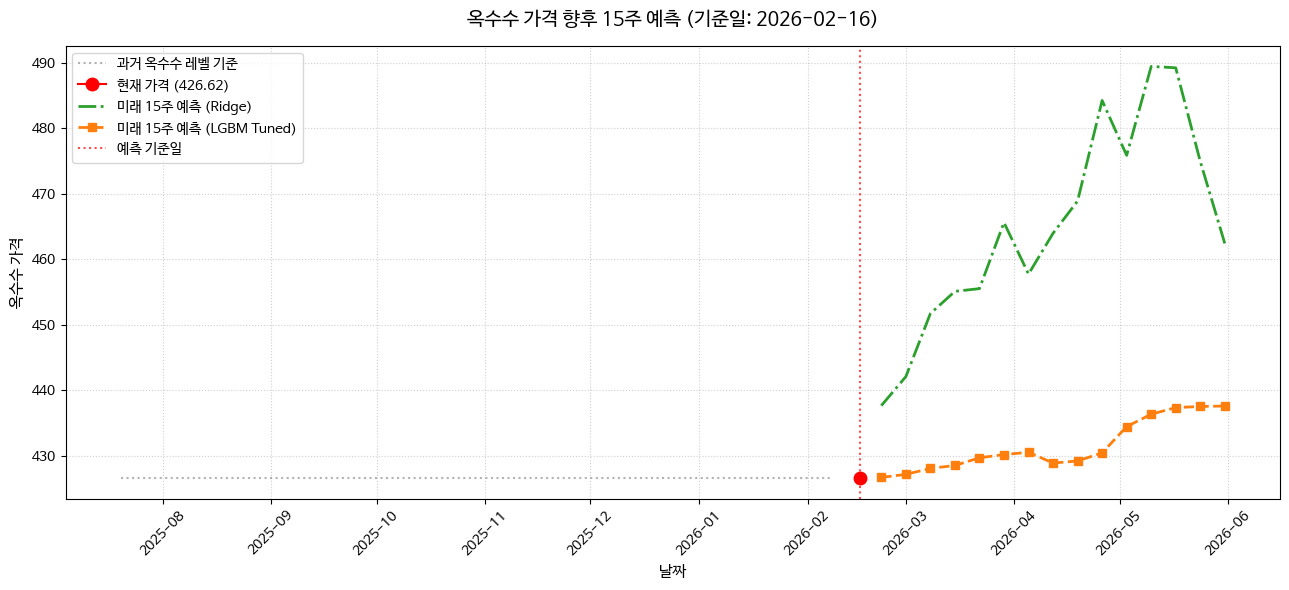

In [20]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -------------------------------------------------------------
# 1. 단일 행 추론 및 시각화 함수 (컬럼 구조 완벽 대응)
# -------------------------------------------------------------
def predict_and_plot_single_row(df_single, models_dict):
  """전달받은 1행짜리 DataFrame 구조('wheat_lag-30' ~ 'wheat_lag30')에 맞춰 추론 및 시각화를 진행하는 함수"""
  # 1. Wheat Lag 피처 명확한 추출 (wheat_lag-15 ~ wheat_lag15)
  wheat_cols = []
  for i in range(-15, 16):
    col_name = f'wheat_lag{i}'  # 예: wheat_lag-15, wheat_lag0, wheat_lag15
    if col_name in df_single.columns:
      wheat_cols.append(col_name)

  # 2. Corn Lag 피처 매핑
  # (만약 df_single에 corn_lag가 없다면, 모델 학습 시 사용한 컬럼명으로 만들어 줍니다)
  base_price = df_single['corn'].values[0]

  # 모델에 들어갈 X_cols 정의 (학습할 때 썼던 컬럼 이름과 동일하게)
  # wheat -15~15 + corn 0~30
  model_wheat_cols = [f'wheat_lag_{i}' for i in range(-15, 16)]
  model_corn_cols = [f'corn_lag_{i}' for i in range(0, 31)]
  model_X_cols = model_wheat_cols + model_corn_cols

  # 입력 데이터프레임 생성 (1, 62)
  X_input = pd.DataFrame(index=[0])

  # Wheat 피처값 채우기
  for i in range(-15, 16):
    actual_col = f'wheat_lag{i}'
    model_col = f'wheat_lag_{i}'
    if actual_col in df_single.columns:
      X_input[model_col] = df_single[actual_col].values[0]
    else:
      X_input[model_col] = df_single['wheat'].values[0]  # 대안값

  # Corn 피처값 채우기
  for i in range(0, 31):
    actual_col = f'corn_lag{i}'
    model_col = f'corn_lag_{i}'
    if actual_col in df_single.columns:
      X_input[model_col] = df_single[actual_col].values[0]
    else:
      # corn_lag 컬럼이 따로 없는 경우 현재 corn 가격으로 대체
      X_input[model_col] = base_price

  # 모델 컬럼 순서 고정
  X_input = X_input[model_X_cols]

  # 기준 정보
  base_date = pd.to_datetime(df_single['date'].values[0])

  # 3. 날짜 축 생성
  past_dates = pd.date_range(end=base_date, periods=31, freq='W')[:-1]
  future_dates = pd.date_range(start=base_date, periods=15, freq='W')

  # 과거 30주 옥수수 추이 (데이터에 없으면 기준가로 대체 표시)
  past_corn = [base_price] * 30

  # -------------------------------------------------------------
  # 시각화
  # -------------------------------------------------------------
  plt.figure(figsize=(13, 6))

  # 과거 30주 흐름
  plt.plot(
      past_dates,
      past_corn,
      color='gray',
      label='과거 옥수수 레벨 기준',
      linewidth=1.5,
      linestyle=':',
      alpha=0.6,
  )

  # 현재 시점 (기준일)
  plt.plot(
      base_date,
      base_price,
      marker='o',
      color='red',
      markersize=9,
      label=f'현재 가격 ({base_price:.2f})',
  )

  # 각 모델별 15주 미래 추론
  colors = ['#2ca02c', '#ff7f0e', '#1f77b4', '#9467bd']
  linestyles = ['-.', '--', '-', ':']

  for idx, (name, model) in enumerate(models_dict.items()):
    # 15주 미래 차분(Diff) 예측
    pred_diff = model.predict(X_input)[0]

    # 현재 가격을 더해 실제 레벨로 복원
    pred_price = base_price + pred_diff

    # 스무딩
    if 'LGBM' in name or 'Tree' in name:
      pred_price = (
          pd.Series(pred_price)
          .rolling(window=3, min_periods=1, center=True)
          .mean()
          .values
      )

    plt.plot(
        future_dates,
        pred_price,
        label=f'미래 15주 예측 ({name})',
        color=colors[idx % len(colors)],
        linestyle=linestyles[idx % len(linestyles)],
        linewidth=2,
        marker='s' if 'LGBM' in name else None,
    )

  plt.axvline(
      x=base_date, color='red', linestyle=':', alpha=0.7, label='예측 기준일'
  )

  plt.title(
      f'옥수수 가격 향후 15주 예측 (기준일: {base_date.strftime("%Y-%m-%d")})',
      fontsize=14,
      pad=15,
  )
  plt.xlabel('날짜', fontsize=11)
  plt.ylabel('옥수수 가격', fontsize=11)
  plt.grid(True, linestyle=':', alpha=0.6)
  plt.legend(fontsize=10, loc='upper left')
  plt.xticks(rotation=45)

  plt.tight_layout()
  plt.show()


# -------------------------------------------------------------
# 2. 실행
# -------------------------------------------------------------
predict_and_plot_single_row(df_single_row, models)

In [24]:
import pandas as pd


def get_prediction_dataframe(df_single, models_dict):
  """단일 행(1-Row) 데이터프레임을 받아 미래 15주 예측값을 모델별 DataFrame 형태로 반환하는 함수"""
  # 1. 기준 정보 추출
  base_date = pd.to_datetime(df_single['date'].values[0])
  base_price = df_single['corn'].values[0]

  # 2. 미래 15주 주간 날짜 리스트 생성
  future_dates = pd.date_range(start=base_date, periods=15, freq='W')

  # 3. 모델 입력용 X_input 매핑 생성 (wheat -15~15, corn 0~30)
  model_wheat_cols = [f'wheat_lag_{i}' for i in range(-15, 16)]
  model_corn_cols = [f'corn_lag_{i}' for i in range(0, 31)]
  model_X_cols = model_wheat_cols + model_corn_cols

  X_input = pd.DataFrame(index=[0])

  # Wheat 피처 매핑
  for i in range(-15, 16):
    actual_col = f'wheat_lag{i}'
    model_col = f'wheat_lag_{i}'
    if actual_col in df_single.columns:
      X_input[model_col] = df_single[actual_col].values[0]
    else:
      X_input[model_col] = df_single['wheat'].values[0]

  # Corn 피처 매핑
  for i in range(0, 31):
    actual_col = f'corn_lag{i}'
    model_col = f'corn_lag_{i}'
    if actual_col in df_single.columns:
      X_input[model_col] = df_single[actual_col].values[0]
    else:
      X_input[model_col] = base_price

  X_input = X_input[model_X_cols]

  # 4. 결과 저장용 데이터프레임 기본 구조 세팅
  df_result = pd.DataFrame({
      'Week': [f'+{i}주차' for i in range(1, 16)],
      'Date': future_dates.strftime('%Y-%m-%d'),
  })

  # 5. 각 모델별 추론 및 실제 가격 복원
  for name, model in models_dict.items():
    # 15주 미래 차분(Diff) 예측
    pred_diff = model.predict(X_input)[0]

    # 현재 가격을 더해 실제 가격으로 복원
    pred_price = base_price + pred_diff

    # 스무딩 옵션 적용 (LGBM 및 트리 계열)
    if 'LGBM' in name or 'Tree' in name:
      pred_price = (
          pd.Series(pred_price)
          .rolling(window=3, min_periods=1, center=True)
          .mean()
          .values
      )

    # 반올림 처리하여 컬럼 추가
    df_result[f'{name}_예측가'] = np.round(pred_price, 2)

  return df_result

In [25]:
# 함수 실행
df_pred_15w = get_prediction_dataframe(df_single_row, models)

# 결과 데이터프레임 확인
display(df_pred_15w)

,Week,Date,Ridge_예측가,LGBM Tuned_예측가
0,+1주차,2026-02-22,437.67,426.72
1,+2주차,2026-03-01,442.09,427.18
2,+3주차,2026-03-08,451.72,428.09
3,+4주차,2026-03-15,455.10,428.54
4,+5주차,2026-03-22,455.52,429.71
5,+6주차,2026-03-29,465.60,430.20
6,+7주차,2026-04-05,457.74,430.55
7,+8주차,2026-04-12,463.96,428.91
8,+9주차,2026-04-19,468.89,429.23
9,+10주차,2026-04-26,484.23,430.47


=== 🏆 전체 15주 통합 성능 비교 (Overall Metrics) ===


,Model,MAE (평균 절대 오차),RMSE (평균 제곱근 오차),R² Score (결정계수)
0,Ridge,24.524,31.755,0.855
1,LightGBM,25.125,34.062,0.831



=== 📅 주차별 오차 추이 비교 (Weekly Metrics - 앞/뒤 5개) ===


,Week,Ridge_MAE,LGBM_MAE,Ridge_RMSE,LGBM_RMSE,MAE 우세 모델
0,+1주차,8.522,8.826,11.125,12.634,Ridge
1,+2주차,13.765,14.411,18.471,19.758,Ridge
2,+3주차,18.084,17.564,23.654,23.610,LightGBM
3,+4주차,20.410,18.854,26.345,25.009,LightGBM
4,+5주차,21.224,20.108,27.633,26.594,LightGBM


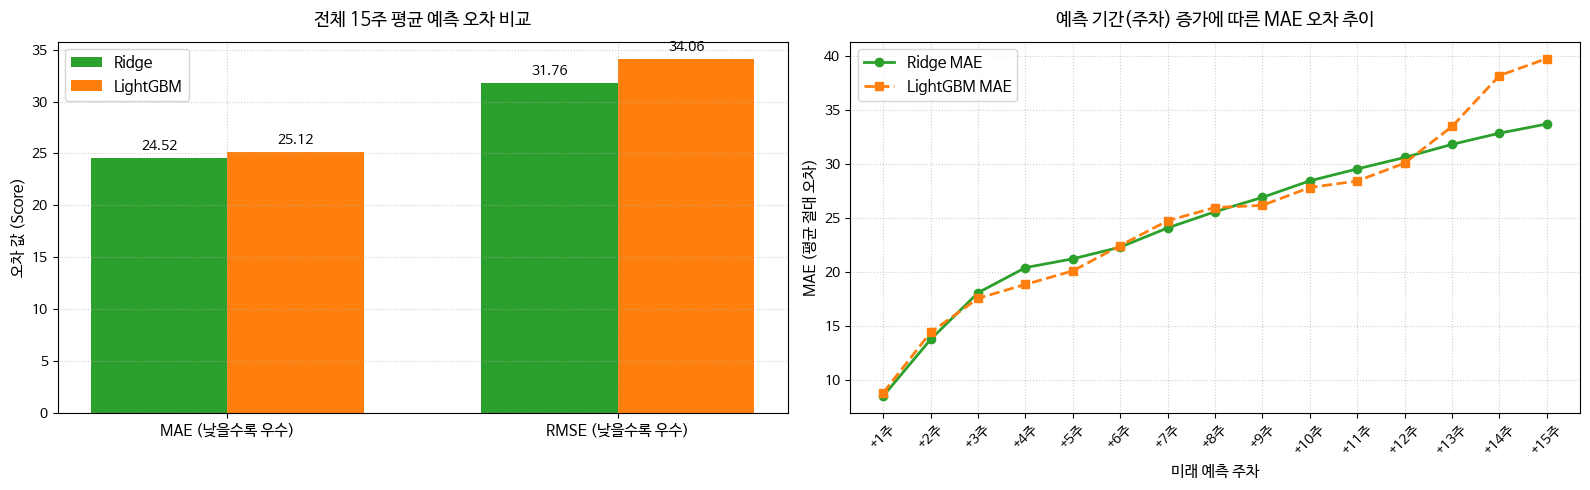

In [28]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 평가 지표 모듈
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. 테스트 세트 전체 추론 및 실제 가격 복원
# -------------------------------------------------------------
# X_test: (N_test, 62)
# y_test_diff: (N_test, 15) -> 차분 Target 실제값

# 각 모델별 차분 예측
y_pred_diff_ridge = ridge_model.predict(X_test)  # (N_test, 15)
y_pred_diff_lgbm = lgbm_model.predict(X_test)  # (N_test, 15)

# 평가를 위해 '실제 가격 레벨' 및 '예측 가격 레벨'로 복원
# (X_test의 corn_lag_0 컬럼 = 당시의 현재가)
base_corn_prices = X_test['corn_lag_0'].values.reshape(-1, 1)

y_true_price = base_corn_prices + y_test_diff.values
y_pred_price_ridge = base_corn_prices + y_pred_diff_ridge
y_pred_price_lgbm = base_corn_prices + y_pred_diff_lgbm


# -------------------------------------------------------------
# 2. 성능 평가 지표 계산 함수 (MAE, RMSE, R2)
# -------------------------------------------------------------
def calculate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2


# Overall (전체 15주 통합) 성능 계산
ridge_mae, ridge_rmse, ridge_r2 = calculate_metrics(
    y_true_price, y_pred_price_ridge
)
lgbm_mae, lgbm_rmse, lgbm_r2 = calculate_metrics(
    y_true_price, y_pred_price_lgbm
)

# 1. 요약 데이터프레임 생성 및 출력
df_overall_metrics = pd.DataFrame({
    'Model': ['Ridge', 'LightGBM'],
    'MAE (평균 절대 오차)': [round(ridge_mae, 3), round(lgbm_mae, 3)],
    'RMSE (평균 제곱근 오차)': [
        round(ridge_rmse, 3),
        round(lgbm_rmse, 3),
    ],
    'R² Score (결정계수)': [round(ridge_r2, 3), round(lgbm_r2, 3)],
})

print('=== 🏆 전체 15주 통합 성능 비교 (Overall Metrics) ===')
display(df_overall_metrics)

# -------------------------------------------------------------
# 3. 주차별(1주차 ~ 15주차) MAE 성능 비교 테이블 생성
# -------------------------------------------------------------
weekly_metrics = []
for i in range(15):
  week_label = f'+{i+1}주차'

  r_mae, r_rmse, _ = calculate_metrics(
      y_true_price[:, i], y_pred_price_ridge[:, i]
  )
  l_mae, l_rmse, _ = calculate_metrics(
      y_true_price[:, i], y_pred_price_lgbm[:, i]
  )

  weekly_metrics.append({
      'Week': week_label,
      'Ridge_MAE': round(r_mae, 3),
      'LGBM_MAE': round(l_mae, 3),
      'Ridge_RMSE': round(r_rmse, 3),
      'LGBM_RMSE': round(l_rmse, 3),
      'MAE 우세 모델': 'Ridge' if r_mae < l_mae else 'LightGBM',
  })

df_weekly_metrics = pd.DataFrame(weekly_metrics)

print('\n=== 📅 주차별 오차 추이 비교 (Weekly Metrics - 앞/뒤 5개) ===')
display(df_weekly_metrics.head(5))

# -------------------------------------------------------------
# 4. 성능 비교 시각화 (2개 서브플롯)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [왼쪽 그래프] Overall 지표 비교 Bar Chart
x_labels = ['MAE (낮을수록 우수)', 'RMSE (낮을수록 우수)']
ridge_scores = [ridge_mae, ridge_rmse]
lgbm_scores = [lgbm_mae, lgbm_rmse]

x = np.arange(len(x_labels))
width = 0.35

rects1 = axes[0].bar(
    x - width / 2, ridge_scores, width, label='Ridge', color='#2ca02c'
)
rects2 = axes[0].bar(
    x + width / 2, lgbm_scores, width, label='LightGBM', color='#ff7f0e'
)

axes[0].set_ylabel('오차 값 (Score)', fontsize=11)
axes[0].set_title('전체 15주 평균 예측 오차 비교', fontsize=13, pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# 바 위에 값 표시
axes[0].bar_label(rects1, padding=3, fmt='%.2f')
axes[0].bar_label(rects2, padding=3, fmt='%.2f')

# [오른쪽 그래프] 미래 주차별 MAE 오차 증가 추이 (1주차~15주차 Line Chart)
weeks = [f'+{i+1}주' for i in range(15)]

axes[1].plot(
    weeks,
    df_weekly_metrics['Ridge_MAE'],
    marker='o',
    color='#2ca02c',
    linewidth=2,
    label='Ridge MAE',
)
axes[1].plot(
    weeks,
    df_weekly_metrics['LGBM_MAE'],
    marker='s',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
    label='LightGBM MAE',
)

axes[1].set_xlabel('미래 예측 주차', fontsize=11)
axes[1].set_ylabel('MAE (평균 절대 오차)', fontsize=11)
axes[1].set_title(
    '예측 기간(주차) 증가에 따른 MAE 오차 추이', fontsize=13, pad=12
)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=11)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Model,MAE (평균 절대 오차),RMSE (평균 제곱근 오차),R² Score (결정계수)
0,Ridge,24.524,31.755,0.855
1,LightGBM,24.344,33.082,0.841
2,SARIMAX (외생변수 반영),65.517,86.706,-0.099


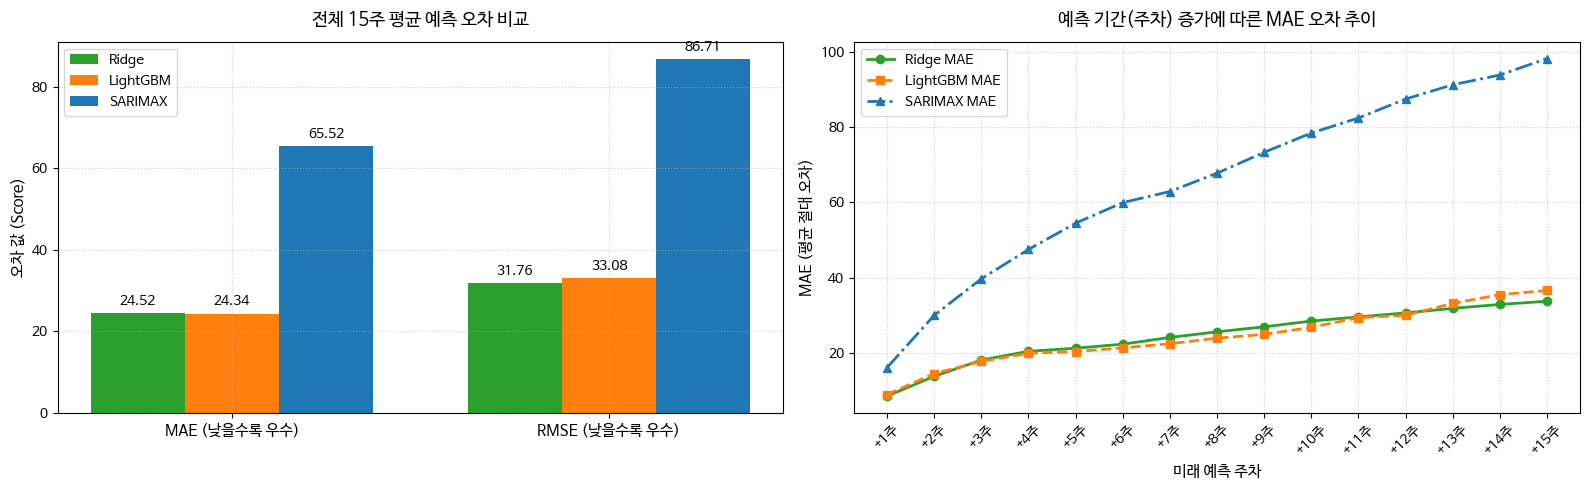

In [29]:
import os
import platform
import warnings
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. SARIMAX Multi-Step 예측 모듈 구축
# -------------------------------------------------------------
# SARIMAX는 각 주차별(lead 1~15)로 미래 소맥(exog)과 과거 Lag을 매핑하여 구현합니다.


class MultiStepSARIMAX:

  def __init__(self, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0)):
    self.order = order
    self.seasonal_order = seasonal_order
    self.models = []

  def fit(self, X_train, y_train_diff):
    # y_train_diff의 15개 컬럼 각각에 대해 독립 SARIMAX 객체 적합
    self.models = []
    for i in range(15):
      y_single = y_train_diff.iloc[:, i]
      # SARIMAX 모델 적합
      model = SARIMAX(
          endog=y_single,
          exog=X_train,
          order=self.order,
          seasonal_order=self.seasonal_order,
          enforce_stationarity=False,
          enforce_invertibility=False,
      )
      res = model.fit(disp=False)
      self.models.append(res)
    return self

  def predict(self, X_test):
    preds = []
    for i in range(15):
      pred_i = self.models[i].predict(
          start=0, end=len(X_test) - 1, exog=X_test
      )
      preds.append(pred_i.values)
    return np.column_stack(preds)


# -------------------------------------------------------------
# 2. 모델 학습 (Ridge, LightGBM, SARIMAX)
# -------------------------------------------------------------
# Ridge & LGBM
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0)).fit(
    X_train, y_train_diff
)
lgbm_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, random_state=42
    )
).fit(X_train, y_train_diff)

# SARIMAX (order=(1,1,1) 설정: 시계열 차분 및 AR/MA 성분 반영)
sarimax_model = MultiStepSARIMAX(order=(1, 1, 1)).fit(X_train, y_train_diff)

# -------------------------------------------------------------
# 3. 테스트 세트 추론 및 실제 가격 레벨 복원
# -------------------------------------------------------------
base_corn_prices = X_test['corn_lag_0'].values.reshape(-1, 1)
y_true_price = base_corn_prices + y_test_diff.values

# 예측값 복원
y_pred_ridge = base_corn_prices + ridge_model.predict(X_test)
y_pred_lgbm = base_corn_prices + lgbm_model.predict(X_test)
y_pred_sarimax = base_corn_prices + sarimax_model.predict(X_test)


# 지표 계산 함수
def calculate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2


# -------------------------------------------------------------
# 4. 전체 지표 데이터프레임 생성
# -------------------------------------------------------------
r_mae, r_rmse, r_r2 = calculate_metrics(y_true_price, y_pred_ridge)
l_mae, l_rmse, l_r2 = calculate_metrics(y_true_price, y_pred_lgbm)
s_mae, s_rmse, s_r2 = calculate_metrics(y_true_price, y_pred_sarimax)

df_overall_metrics = pd.DataFrame({
    'Model': ['Ridge', 'LightGBM', 'SARIMAX (외생변수 반영)'],
    'MAE (평균 절대 오차)': [round(r_mae, 3), round(l_mae, 3), round(s_mae, 3)],
    'RMSE (평균 제곱근 오차)': [
        round(r_rmse, 3),
        round(l_rmse, 3),
        round(s_rmse, 3),
    ],
    'R² Score (결정계수)': [round(r_r2, 3), round(l_r2, 3), round(s_r2, 3)],
})

print('=== 🏆 3개 모델 통합 성능 비교 (Overall Metrics) ===')
display(df_overall_metrics)

# -------------------------------------------------------------
# 5. 시각화 (MAE 오차 비교 & 주차별 오차 추이)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [왼쪽] MAE / RMSE 비교 Bar Chart
x_labels = ['MAE (낮을수록 우수)', 'RMSE (낮을수록 우수)']
x = np.arange(len(x_labels))
width = 0.25

rects1 = axes[0].bar(
    x - width, [r_mae, r_rmse], width, label='Ridge', color='#2ca02c'
)
rects2 = axes[0].bar(
    x, [l_mae, l_rmse], width, label='LightGBM', color='#ff7f0e'
)
rects3 = axes[0].bar(
    x + width,
    [s_mae, s_rmse],
    width,
    label='SARIMAX',
    color='#1f77b4',
)

axes[0].set_ylabel('오차 값 (Score)', fontsize=11)
axes[0].set_title('전체 15주 평균 예측 오차 비교', fontsize=13, pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[0].bar_label(rects1, padding=3, fmt='%.2f')
axes[0].bar_label(rects2, padding=3, fmt='%.2f')
axes[0].bar_label(rects3, padding=3, fmt='%.2f')

# [오른쪽] 미래 주차별 MAE 오차 추이
weeks = [f'+{i+1}주' for i in range(15)]
ridge_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_ridge[:, i])
    for i in range(15)
]
lgbm_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_lgbm[:, i])
    for i in range(15)
]
sarimax_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_sarimax[:, i])
    for i in range(15)
]

axes[1].plot(
    weeks,
    ridge_w_mae,
    marker='o',
    color='#2ca02c',
    linewidth=2,
    label='Ridge MAE',
)
axes[1].plot(
    weeks,
    lgbm_w_mae,
    marker='s',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
    label='LightGBM MAE',
)
axes[1].plot(
    weeks,
    sarimax_w_mae,
    marker='^',
    color='#1f77b4',
    linewidth=2,
    linestyle='-.',
    label='SARIMAX MAE',
)

axes[1].set_xlabel('미래 예측 주차', fontsize=11)
axes[1].set_ylabel('MAE (평균 절대 오차)', fontsize=11)
axes[1].set_title(
    '예측 기간(주차) 증가에 따른 MAE 오차 추이', fontsize=13, pad=12
)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Model,MAE (평균 절대 오차),RMSE (평균 제곱근 오차),R² Score (결정계수)
0,Ridge (62개 피처 + 규제),24.524,31.755,0.855
1,LightGBM (62개 피처),24.344,33.082,0.841
2,OLS (주차별 1:1 미래 소맥만),28.710,39.384,0.773


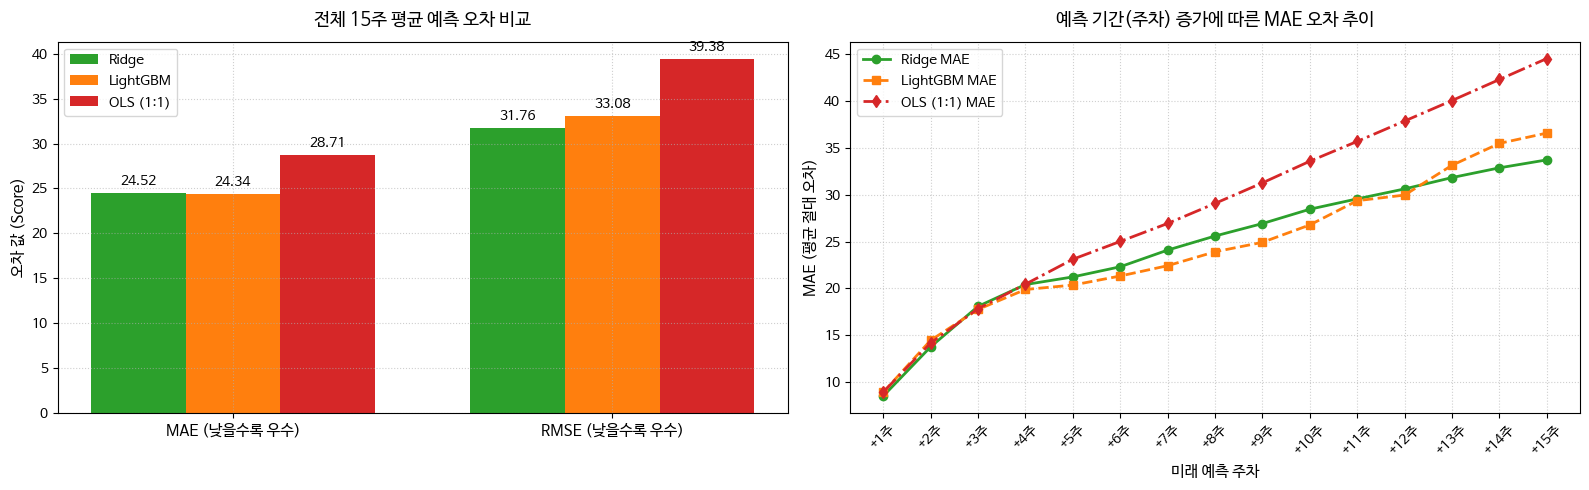

In [30]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False


# -------------------------------------------------------------
# 1. 시점별 1:1 OLS 모델 클래스 구축
# -------------------------------------------------------------
class StepwiseOLS:
  """각 주차별(T+1 ~ T+15)로 미래 소맥 가격 1개 피처만 사용해 옥수수를 예측하는 OLS"""

  def __init__(self):
    self.models = [LinearRegression() for _ in range(15)]

  def fit(self, df_train):
    for i in range(1, 16):
      # X: wheat_lag_-i (미래 T+i 시점 소맥)
      # y: corn_diff_lead_i 또는 corn_lead_i (미래 T+i 시점 옥수수 가격 변화량)
      X_i = df_train[[f'wheat_lag_{-i}']]
      y_i = df_train[f'corn_diff_lead_{i}']
      self.models[i - 1].fit(X_i, y_i)
    return self

  def predict(self, df_test):
    preds = []
    for i in range(1, 16):
      X_i = df_test[[f'wheat_lag_{-i}']]
      pred_i = self.models[i - 1].predict(X_i)
      preds.append(pred_i)
    return np.column_stack(preds)


# -------------------------------------------------------------
# 2. 모델 학습
# -------------------------------------------------------------
# 1) 기존 Ridge & LightGBM (전체 62개 Lag 피처 사용)
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0)).fit(
    X_train, y_train_diff
)
lgbm_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, random_state=42
    )
).fit(X_train, y_train_diff)

# 2) 주차별 1:1 OLS 모델
ols_model = StepwiseOLS().fit(df_clean.iloc[:train_size])

# -------------------------------------------------------------
# 3. 테스트 세트 추론 및 실제 가격 레벨 복원
# -------------------------------------------------------------
base_corn_prices = X_test['corn_lag_0'].values.reshape(-1, 1)
y_true_price = base_corn_prices + y_test_diff.values

y_pred_ridge = base_corn_prices + ridge_model.predict(X_test)
y_pred_lgbm = base_corn_prices + lgbm_model.predict(X_test)
y_pred_ols = base_corn_prices + ols_model.predict(df_clean.iloc[train_size:])


# 지표 계산
def calculate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2


r_mae, r_rmse, r_r2 = calculate_metrics(y_true_price, y_pred_ridge)
l_mae, l_rmse, l_r2 = calculate_metrics(y_true_price, y_pred_lgbm)
o_mae, o_rmse, o_r2 = calculate_metrics(y_true_price, y_pred_ols)

# -------------------------------------------------------------
# 4. 성능 비교 결과 출력
# -------------------------------------------------------------
df_overall_metrics = pd.DataFrame({
    'Model': [
        'Ridge (62개 피처 + 규제)',
        'LightGBM (62개 피처)',
        'OLS (주차별 1:1 미래 소맥만)',
    ],
    'MAE (평균 절대 오차)': [round(r_mae, 3), round(l_mae, 3), round(o_mae, 3)],
    'RMSE (평균 제곱근 오차)': [
        round(r_rmse, 3),
        round(l_rmse, 3),
        round(o_rmse, 3),
    ],
    'R² Score (결정계수)': [round(r_r2, 3), round(l_r2, 3), round(o_r2, 3)],
})

print('=== 🏆 3개 모델 통합 성능 비교 (Overall Metrics) ===')
display(df_overall_metrics)

# -------------------------------------------------------------
# 5. 시각화 (MAE 오차 비교 & 주차별 오차 추이)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [왼쪽] MAE / RMSE 비교 Bar Chart
x_labels = ['MAE (낮을수록 우수)', 'RMSE (낮을수록 우수)']
x = np.arange(len(x_labels))
width = 0.25

rects1 = axes[0].bar(
    x - width, [r_mae, r_rmse], width, label='Ridge', color='#2ca02c'
)
rects2 = axes[0].bar(
    x, [l_mae, l_rmse], width, label='LightGBM', color='#ff7f0e'
)
rects3 = axes[0].bar(
    x + width, [o_mae, o_rmse], width, label='OLS (1:1)', color='#d62728'
)

axes[0].set_ylabel('오차 값 (Score)', fontsize=11)
axes[0].set_title('전체 15주 평균 예측 오차 비교', fontsize=13, pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[0].bar_label(rects1, padding=3, fmt='%.2f')
axes[0].bar_label(rects2, padding=3, fmt='%.2f')
axes[0].bar_label(rects3, padding=3, fmt='%.2f')

# [오른쪽] 미래 주차별 MAE 오차 추이
weeks = [f'+{i+1}주' for i in range(15)]
ridge_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_ridge[:, i])
    for i in range(15)
]
lgbm_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_lgbm[:, i])
    for i in range(15)
]
ols_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_ols[:, i])
    for i in range(15)
]

axes[1].plot(
    weeks,
    ridge_w_mae,
    marker='o',
    color='#2ca02c',
    linewidth=2,
    label='Ridge MAE',
)
axes[1].plot(
    weeks,
    lgbm_w_mae,
    marker='s',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
    label='LightGBM MAE',
)
axes[1].plot(
    weeks,
    ols_w_mae,
    marker='d',
    color='#d62728',
    linewidth=2,
    linestyle='-.',
    label='OLS (1:1) MAE',
)

axes[1].set_xlabel('미래 예측 주차', fontsize=11)
axes[1].set_ylabel('MAE (평균 절대 오차)', fontsize=11)
axes[1].set_title(
    '예측 기간(주차) 증가에 따른 MAE 오차 추이', fontsize=13, pad=12
)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13082
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 62
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,Model,MAE (평균 절대 오차),RMSE (평균 제곱근 오차),R² Score (결정계수)
0,Ridge (62개 피처),24.524,31.755,0.855
1,LightGBM (62개 피처),24.344,33.082,0.841
2,OLS (1:1 소맥만),28.710,39.384,0.773
3,SARIMAX (1:1 소맥 exog),69.903,92.751,-0.253


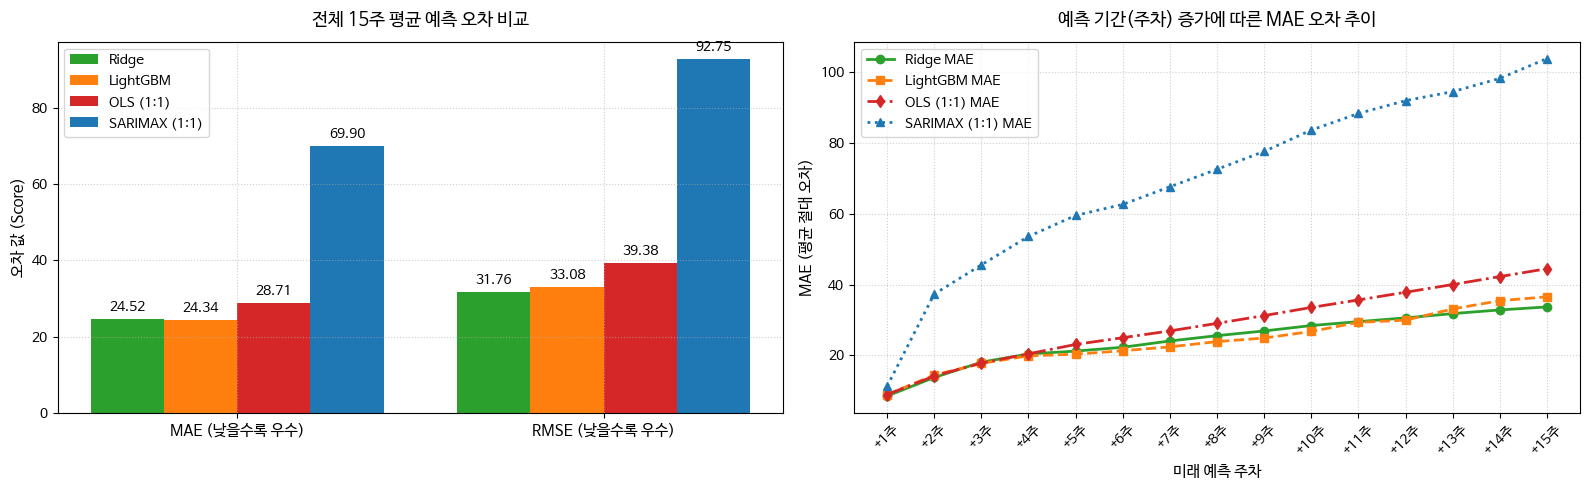

In [31]:
import os
import platform
import warnings
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings('ignore')

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False


# -------------------------------------------------------------
# 1. 시점별 1:1 외생변수 반영 SARIMAX 클래스 구축
# -------------------------------------------------------------
class StepwiseSARIMAX:
  """각 주차별(T+1 ~ T+15)로 해당 시점의 소맥(Wheat_T+k) 1개만 exog로 사용하는 SARIMAX"""

  def __init__(self, order=(1, 1, 1)):
    self.order = order
    self.models = []

  def fit(self, df_train):
    self.models = []
    for i in range(1, 16):
      # Target: T+i 시점 옥수수 가격 차분
      y_i = df_train[f'corn_diff_lead_{i}']
      # Exogenous: T+i 시점 소맥 가격 (wheat_lag_-i)
      X_i = df_train[[f'wheat_lag_{-i}']]

      # 1:1 외생변수 SARIMAX 적합
      model = SARIMAX(
          endog=y_i,
          exog=X_i,
          order=self.order,
          enforce_stationarity=False,
          enforce_invertibility=False,
      )
      res = model.fit(disp=False)
      self.models.append(res)
    return self

  def predict(self, df_test):
    preds = []
    for i in range(1, 16):
      X_i = df_test[[f'wheat_lag_{-i}']]
      pred_i = self.models[i - 1].predict(
          start=0, end=len(df_test) - 1, exog=X_i
      )
      preds.append(pred_i.values)
    return np.column_stack(preds)


# -------------------------------------------------------------
# 2. 모델 학습 (Ridge, LightGBM, OLS, SARIMAX 1:1)
# -------------------------------------------------------------
train_df = df_clean.iloc[:train_size]
test_df = df_clean.iloc[train_size:]

# 1) Ridge & LGBM (전체 Lag 사용)
ridge_model = MultiOutputRegressor(Ridge(alpha=10.0)).fit(
    X_train, y_train_diff
)
lgbm_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=60, learning_rate=0.03, max_depth=3, random_state=42
    )
).fit(X_train, y_train_diff)

# 2) 1:1 OLS (주차별 동시점 소맥만 반영)
class StepwiseOLS:

  def __init__(self):
    self.models = [LinearRegression() for _ in range(15)]

  def fit(self, df_tr):
    for i in range(1, 16):
      self.models[i - 1].fit(
          df_tr[[f'wheat_lag_{-i}']], df_tr[f'corn_diff_lead_{i}']
      )
    return self

  def predict(self, df_te):
    return np.column_stack([
        self.models[i - 1].predict(df_te[[f'wheat_lag_{-i}']])
        for i in range(1, 16)
    ])


ols_model = StepwiseOLS().fit(train_df)

# 3) 1:1 SARIMAX (주차별 동시점 소맥만 exog로 반영)
sarimax_1to1_model = StepwiseSARIMAX(order=(1, 1, 1)).fit(train_df)

# -------------------------------------------------------------
# 3. 추론 및 실제 가격 복원
# -------------------------------------------------------------
base_corn_prices = X_test['corn_lag_0'].values.reshape(-1, 1)
y_true_price = base_corn_prices + y_test_diff.values

y_pred_ridge = base_corn_prices + ridge_model.predict(X_test)
y_pred_lgbm = base_corn_prices + lgbm_model.predict(X_test)
y_pred_ols = base_corn_prices + ols_model.predict(test_df)
y_pred_sarimax_1to1 = base_corn_prices + sarimax_1to1_model.predict(test_df)


# 지표 계산
def calculate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2


r_mae, r_rmse, r_r2 = calculate_metrics(y_true_price, y_pred_ridge)
l_mae, l_rmse, l_r2 = calculate_metrics(y_true_price, y_pred_lgbm)
o_mae, o_rmse, o_r2 = calculate_metrics(y_true_price, y_pred_ols)
s_mae, s_rmse, s_r2 = calculate_metrics(y_true_price, y_pred_sarimax_1to1)

# -------------------------------------------------------------
# 4. 성능 비교 결과 출력
# -------------------------------------------------------------
df_overall_metrics = pd.DataFrame({
    'Model': [
        'Ridge (62개 피처)',
        'LightGBM (62개 피처)',
        'OLS (1:1 소맥만)',
        'SARIMAX (1:1 소맥 exog)',
    ],
    'MAE (평균 절대 오차)': [
        round(r_mae, 3),
        round(l_mae, 3),
        round(o_mae, 3),
        round(s_mae, 3),
    ],
    'RMSE (평균 제곱근 오차)': [
        round(r_rmse, 3),
        round(l_rmse, 3),
        round(o_rmse, 3),
        round(s_rmse, 3),
    ],
    'R² Score (결정계수)': [
        round(r_r2, 3),
        round(l_r2, 3),
        round(o_r2, 3),
        round(s_r2, 3),
    ],
})

print('=== 🏆 4개 모델 통합 성능 비교 (Overall Metrics) ===')
display(df_overall_metrics)

# -------------------------------------------------------------
# 5. 시각화 (MAE 오차 비교 & 주차별 오차 추이)
# -------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# [왼쪽] MAE / RMSE 비교 Bar Chart
x_labels = ['MAE (낮을수록 우수)', 'RMSE (낮을수록 우수)']
x = np.arange(len(x_labels))
width = 0.2

rects1 = axes[0].bar(
    x - 1.5 * width, [r_mae, r_rmse], width, label='Ridge', color='#2ca02c'
)
rects2 = axes[0].bar(
    x - 0.5 * width, [l_mae, l_rmse], width, label='LightGBM', color='#ff7f0e'
)
rects3 = axes[0].bar(
    x + 0.5 * width, [o_mae, o_rmse], width, label='OLS (1:1)', color='#d62728'
)
rects4 = axes[0].bar(
    x + 1.5 * width,
    [s_mae, s_rmse],
    width,
    label='SARIMAX (1:1)',
    color='#1f77b4',
)

axes[0].set_ylabel('오차 값 (Score)', fontsize=11)
axes[0].set_title('전체 15주 평균 예측 오차 비교', fontsize=13, pad=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[0].bar_label(rects1, padding=3, fmt='%.2f')
axes[0].bar_label(rects2, padding=3, fmt='%.2f')
axes[0].bar_label(rects3, padding=3, fmt='%.2f')
axes[0].bar_label(rects4, padding=3, fmt='%.2f')

# [오른쪽] 미래 주차별 MAE 오차 추이
weeks = [f'+{i+1}주' for i in range(15)]
ridge_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_ridge[:, i])
    for i in range(15)
]
lgbm_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_lgbm[:, i])
    for i in range(15)
]
ols_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_ols[:, i])
    for i in range(15)
]
sarimax_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_sarimax_1to1[:, i])
    for i in range(15)
]

axes[1].plot(
    weeks,
    ridge_w_mae,
    marker='o',
    color='#2ca02c',
    linewidth=2,
    label='Ridge MAE',
)
axes[1].plot(
    weeks,
    lgbm_w_mae,
    marker='s',
    color='#ff7f0e',
    linewidth=2,
    linestyle='--',
    label='LightGBM MAE',
)
axes[1].plot(
    weeks,
    ols_w_mae,
    marker='d',
    color='#d62728',
    linewidth=2,
    linestyle='-.',
    label='OLS (1:1) MAE',
)
axes[1].plot(
    weeks,
    sarimax_w_mae,
    marker='^',
    color='#1f77b4',
    linewidth=2,
    linestyle=':',
    label='SARIMAX (1:1) MAE',
)

axes[1].set_xlabel('미래 예측 주차', fontsize=11)
axes[1].set_ylabel('MAE (평균 절대 오차)', fontsize=11)
axes[1].set_title(
    '예측 기간(주차) 증가에 따른 MAE 오차 추이', fontsize=13, pad=12
)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(fontsize=10)
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# -------------------------------------------------------------
# 1. 피처 분리 (소맥 변수 포함 여부)
# -------------------------------------------------------------
# [A] 소맥 미포함: 과거 옥수수 Lag 피처만 사용 (corn_lag_0 ~ corn_lag_29 등)
corn_only_cols = [col for col in X_train.columns if col.startswith('corn_lag_')]
X_train_no_wheat = X_train[corn_only_cols]
X_test_no_wheat = X_test[corn_only_cols]

# [B] 소맥 포함: 전체 피처 (과거 Lag + 미래 소맥 T+1~T+15)
# X_train, X_test 그대로 사용

# -------------------------------------------------------------
# 2. 모델 학습 및 추론
# -------------------------------------------------------------
# Model A: 소맥 정보 없이 옥수수 자기상관만 학습
model_no_wheat = MultiOutputRegressor(Ridge(alpha=10.0)).fit(X_train_no_wheat, y_train_diff)
y_pred_no_wheat = base_corn_prices + model_no_wheat.predict(X_test_no_wheat)

# Model B: 미래 소맥 정보(Exog) 반영 학습
model_with_wheat = MultiOutputRegressor(Ridge(alpha=10.0)).fit(X_train, y_train_diff)
y_pred_with_wheat = base_corn_prices + model_with_wheat.predict(X_test)

# -------------------------------------------------------------
# 3. 유의미성 검증 결과 비교
# -------------------------------------------------------------
mae_no_wheat = mean_absolute_error(y_true_price, y_pred_no_wheat)
r2_no_wheat = r2_score(y_true_price, y_pred_no_wheat)

mae_with_wheat = mean_absolute_error(y_true_price, y_pred_with_wheat)
r2_with_wheat = r2_score(y_true_price, y_pred_with_wheat)

# 개선율 계산
mae_imprv = ((mae_no_wheat - mae_with_wheat) / mae_no_wheat) * 100
r2_imprv = r2_with_wheat - r2_no_wheat

df_comparison = pd.DataFrame({
    '구분': ['소맥 변수 미포함 (Corn Only)', '소맥 변수 포함 (Exogenous)', '성능 개선폭'],
    'MAE (오차)': [round(mae_no_wheat, 3), round(mae_with_wheat, 3), f"{round(mae_imprv, 2)}% 감소 🟢"],
    'R² Score (설명력)': [round(r2_no_wheat, 3), round(r2_with_wheat, 3), f"+{round(r2_imprv, 3)} 증가 🟢"]
})

print("=== 🧪 미래 소맥 변수 유무에 따른 성능 개선 검증 ===")
display(df_comparison)

=== 🧪 미래 소맥 변수 유무에 따른 성능 개선 검증 ===


,구분,MAE (오차),R² Score (설명력)
0,소맥 변수 미포함 (Corn Only),27.121,0.808
1,소맥 변수 포함 (Exogenous),24.524,0.855
2,성능 개선폭,9.58% 감소 🟢,+0.047 증가 🟢


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000362 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6541
[LightGBM] [Info] Number of data points in the train set: 631, number of used features: 31
[LightGBM] [Info] Start training from score 0.416521
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,구분,MAE (오차),RMSE (제곱근 오차),R² Score (설명력)
0,LightGBM (소맥 변수 미포함 - Corn Only),30.371,44.867,0.703
1,LightGBM (소맥 변수 포함 - Exogenous),24.353,33.524,0.836
2,성능 개선폭,19.82% 감소 🟢,25.28% 감소 🟢,+0.133 증가 🟢


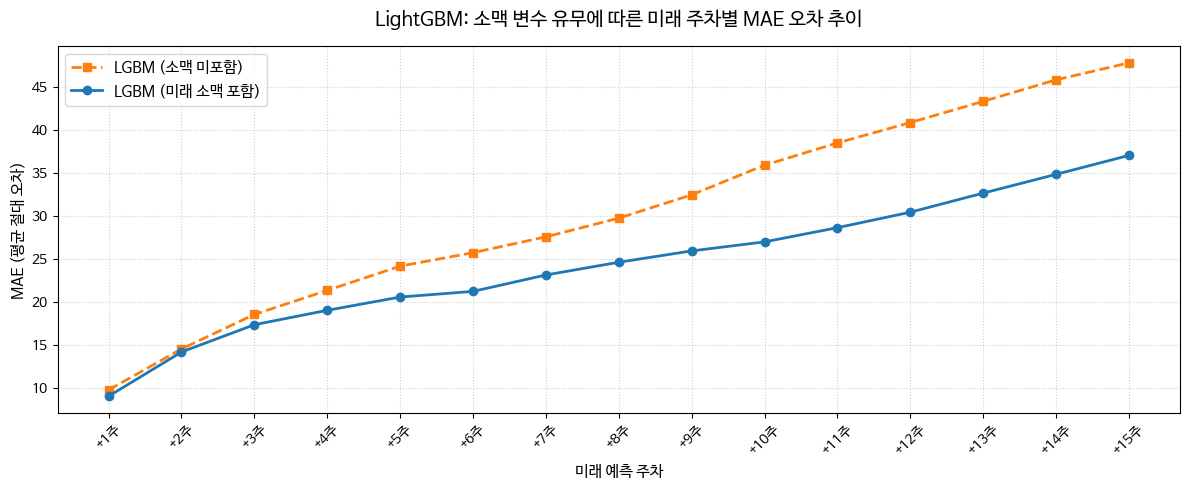

In [33]:
import os
import platform
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

# -------------------------------------------------------------
# 0. 한글 폰트 설정
# -------------------------------------------------------------
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
if os.path.exists(font_path):
  font_name = fm.FontProperties(fname=font_path).get_name()
  plt.rc('font', family=font_name)
else:
  if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
  elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False

# -------------------------------------------------------------
# 1. 피처 분리 (소맥 변수 포함 여부)
# -------------------------------------------------------------
# [A] 소맥 미포함: 과거 옥수수 Lag 피처만 사용 (corn_lag_0 ~ corn_lag_30)
corn_only_cols = [c for c in X_train.columns if c.startswith('corn_lag_')]
X_train_no_wheat = X_train[corn_only_cols]
X_test_no_wheat = X_test[corn_only_cols]

# [B] 소맥 포함: 전체 피처 (X_train, X_test 그대로 사용)

# -------------------------------------------------------------
# 2. LightGBM 모델 학습 (Tuned Hyperparameters 적용)
# -------------------------------------------------------------
lgbm_params = dict(
    n_estimators=60,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=7,
    min_child_samples=15,
    subsample=0.7,
    colsample_bytree=0.5,
    random_state=42,
)

# Model 1: 소맥 미포함 LightGBM
lgbm_no_wheat = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(
    X_train_no_wheat, y_train_diff
)

# Model 2: 소맥 포함 LightGBM
lgbm_with_wheat = MultiOutputRegressor(LGBMRegressor(**lgbm_params)).fit(
    X_train, y_train_diff
)

# -------------------------------------------------------------
# 3. 추론 및 가격 레벨 복원
# -------------------------------------------------------------
base_corn_prices = X_test['corn_lag_0'].values.reshape(-1, 1)
y_true_price = base_corn_prices + y_test_diff.values

y_pred_no_wheat = base_corn_prices + lgbm_no_wheat.predict(X_test_no_wheat)
y_pred_with_wheat = base_corn_prices + lgbm_with_wheat.predict(X_test)


# 스무딩 함수 (LGBM 특유의 계단현상 완화)
def apply_smoothing(y_pred):
  y_smoothed = np.zeros_like(y_pred)
  for i in range(len(y_pred)):
    y_smoothed[i] = (
        pd.Series(y_pred[i])
        .rolling(window=3, min_periods=1, center=True)
        .mean()
        .values
    )
  return y_smoothed


y_pred_no_wheat_s = apply_smoothing(y_pred_no_wheat)
y_pred_with_wheat_s = apply_smoothing(y_pred_with_wheat)


# 지표 계산
def calculate_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2


mae_no, rmse_no, r2_no = calculate_metrics(y_true_price, y_pred_no_wheat_s)
mae_with, rmse_with, r2_with = calculate_metrics(
    y_true_price, y_pred_with_wheat_s
)

# -------------------------------------------------------------
# 4. 종합 성능 비교표 출력
# -------------------------------------------------------------
mae_imprv = ((mae_no - mae_with) / mae_no) * 100
r2_imprv = r2_with - r2_no

df_lgbm_comparison = pd.DataFrame({
    '구분': [
        'LightGBM (소맥 변수 미포함 - Corn Only)',
        'LightGBM (소맥 변수 포함 - Exogenous)',
        '성능 개선폭',
    ],
    'MAE (오차)': [
        round(mae_no, 3),
        round(mae_with, 3),
        f'{round(mae_imprv, 2)}% 감소 🟢',
    ],
    'RMSE (제곱근 오차)': [
        round(rmse_no, 3),
        round(rmse_with, 3),
        f'{round(((rmse_no - rmse_with)/rmse_no)*100, 2)}% 감소 🟢',
    ],
    'R² Score (설명력)': [
        round(r2_no, 3),
        round(r2_with, 3),
        f'+{round(r2_imprv, 3)} 증가 🟢',
    ],
})

print('=== 🧪 LightGBM 내 소맥 변수 유무에 따른 성능 비교 ===')
display(df_lgbm_comparison)

# -------------------------------------------------------------
# 5. 주차별 MAE 오차 추이 시각화
# -------------------------------------------------------------
weeks = [f'+{i+1}주' for i in range(15)]
lgbm_no_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_no_wheat_s[:, i])
    for i in range(15)
]
lgbm_with_w_mae = [
    mean_absolute_error(y_true_price[:, i], y_pred_with_wheat_s[:, i])
    for i in range(15)
]

plt.figure(figsize=(12, 5))
plt.plot(
    weeks,
    lgbm_no_w_mae,
    marker='s',
    color='#ff7f0e',
    linestyle='--',
    linewidth=2,
    label='LGBM (소맥 미포함)',
)
plt.plot(
    weeks,
    lgbm_with_w_mae,
    marker='o',
    color='#1f77b4',
    linewidth=2,
    label='LGBM (미래 소맥 포함)',
)

plt.title(
    'LightGBM: 소맥 변수 유무에 따른 미래 주차별 MAE 오차 추이',
    fontsize=14,
    pad=15,
)
plt.xlabel('미래 예측 주차', fontsize=11)
plt.ylabel('MAE (평균 절대 오차)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
df_all.tail(30)

,Unnamed: 0,date,corn,wheat,wheat_lag-30,wheat_lag-29,wheat_lag-28,wheat_lag-27,wheat_lag-26,wheat_lag-25,...,wheat_lag21,wheat_lag22,wheat_lag23,wheat_lag24,wheat_lag25,wheat_lag26,wheat_lag27,wheat_lag28,wheat_lag29,wheat_lag30
834,834,2025-12-29,440.1250,509.3125,NaN,686.4,663.05,620.05,592.1875,598.3500,...,513.2500,526.4000,542.4000,540.1000,548.5500,552.0000,545.3500,556.8750,536.2000,543.7000
835,835,2026-01-05,445.4000,515.2500,NaN,NaN,686.40,663.05,620.0500,592.1875,...,511.5500,513.2500,526.4000,542.4000,540.1000,548.5500,552.0000,545.3500,556.8750,536.2000
836,836,2026-01-12,421.6500,512.5500,NaN,NaN,NaN,686.40,663.0500,620.0500,...,526.3000,511.5500,513.2500,526.4000,542.4000,540.1000,548.5500,552.0000,545.3500,556.8750
837,837,2026-01-19,425.0000,515.7500,NaN,NaN,NaN,NaN,686.4000,663.0500,...,529.8000,526.3000,511.5500,513.2500,526.4000,542.4000,540.1000,548.5500,552.0000,545.3500
838,838,2026-01-26,428.7500,532.2500,NaN,NaN,NaN,NaN,NaN,686.4000,...,522.2500,529.8000,526.3000,511.5500,513.2500,526.4000,542.4000,540.1000,548.5500,552.0000
839,839,2026-02-02,429.8000,529.6500,NaN,NaN,NaN,NaN,NaN,NaN,...,520.8000,522.2500,529.8000,526.3000,511.5500,513.2500,526.4000,542.4000,540.1000,548.5500
840,840,2026-02-09,429.6000,539.1000,NaN,NaN,NaN,NaN,NaN,NaN,...,526.8000,520.8000,522.2500,529.8000,526.3000,511.5500,513.2500,526.4000,542.4000,540.1000
841,841,2026-02-16,426.6250,557.9375,NaN,NaN,NaN,NaN,NaN,NaN,...,519.5000,526.8000,520.8000,522.2500,529.8000,526.3000,511.5500,513.2500,526.4000,542.4000
842,842,2026-02-23,440.0000,576.5500,NaN,NaN,NaN,NaN,NaN,NaN,...,513.3500,519.5000,526.8000,520.8000,522.2500,529.8000,526.3000,511.5500,513.2500,526.4000
843,843,2026-03-02,450.0000,584.0000,NaN,NaN,NaN,NaN,NaN,NaN,...,506.3500,513.3500,519.5000,526.8000,520.8000,522.2500,529.8000,526.3000,511.5500,513.2500


In [27]:
df_pred_15w.to_csv("/content/drive/MyDrive/df_pred_15w.csv")

In [ ]:
/content/drive/MyDrive/df_pred_15w.csv

In [19]:
print(df_single_row.columns.tolist())

['Unnamed: 0', 'date', 'corn', 'wheat', 'wheat_lag-30', 'wheat_lag-29', 'wheat_lag-28', 'wheat_lag-27', 'wheat_lag-26', 'wheat_lag-25', 'wheat_lag-24', 'wheat_lag-23', 'wheat_lag-22', 'wheat_lag-21', 'wheat_lag-20', 'wheat_lag-19', 'wheat_lag-18', 'wheat_lag-17', 'wheat_lag-16', 'wheat_lag-15', 'wheat_lag-14', 'wheat_lag-13', 'wheat_lag-12', 'wheat_lag-11', 'wheat_lag-10', 'wheat_lag-9', 'wheat_lag-8', 'wheat_lag-7', 'wheat_lag-6', 'wheat_lag-5', 'wheat_lag-4', 'wheat_lag-3', 'wheat_lag-2', 'wheat_lag-1', 'wheat_lag0', 'wheat_lag1', 'wheat_lag2', 'wheat_lag3', 'wheat_lag4', 'wheat_lag5', 'wheat_lag6', 'wheat_lag7', 'wheat_lag8', 'wheat_lag9', 'wheat_lag10', 'wheat_lag11', 'wheat_lag12', 'wheat_lag13', 'wheat_lag14', 'wheat_lag15', 'wheat_lag16', 'wheat_lag17', 'wheat_lag18', 'wheat_lag19', 'wheat_lag20', 'wheat_lag21', 'wheat_lag22', 'wheat_lag23', 'wheat_lag24', 'wheat_lag25', 'wheat_lag26', 'wheat_lag27', 'wheat_lag28', 'wheat_lag29', 'wheat_lag30']


In [17]:
df_single_row[['wheat_lag_-15', 'wheat_lag_-14', 'wheat_lag_-13', 'wheat_lag_-12',\n       'wheat_lag_-11', 'wheat_lag_-10', 'wheat_lag_-9', 'wheat_lag_-8',\n       'wheat_lag_-7', 'wheat_lag_-6', 'wheat_lag_-5', 'wheat_lag_-4',\n       'wheat_lag_-3', 'wheat_lag_-2', 'wheat_lag_-1', 'wheat_lag_0',\n       'wheat_lag_1', 'wheat_lag_2', 'wheat_lag_3', 'wheat_lag_4',\n       'wheat_lag_5', 'wheat_lag_6', 'wheat_lag_7', 'wheat_lag_8',\n       'wheat_lag_9', 'wheat_lag_10', 'wheat_lag_11', 'wheat_lag_12',\n       'wheat_lag_13', 'wheat_lag_14', 'wheat_lag_15', 'corn_lag_0',\n       'corn_lag_1', 'corn_lag_2', 'corn_lag_3', 'corn_lag_4', 'corn_lag_5',\n       'corn_lag_6', 'corn_lag_7', 'corn_lag_8', 'corn_lag_9', 'corn_lag_10',\n       'corn_lag_11', 'corn_lag_12', 'corn_lag_13', 'corn_lag_14',\n       'corn_lag_15', 'corn_lag_16', 'corn_lag_17', 'corn_lag_18',\n       'corn_lag_19', 'corn_lag_20', 'corn_lag_21', 'corn_lag_22',\n       'corn_lag_23', 'corn_lag_24', 'corn_lag_25', 'corn_lag_26',\n       'corn_lag_27', 'corn_lag_28', 'corn_lag_29', 'corn_lag_30']]

SyntaxError: unexpected character after line continuation character (2137146730.py, line 1)

In [7]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
